# Regresión lineal simple

## Ejemplo 1

Importar librerias.
Se utiliza numpy para manipular datos, mientras que matplotlib permite realizar gráficas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Creación del conjunto de datos:
En este caso, se quiere predecir el precio de una casa de acuerdo a tamaño, por lo que los datos son:
X = variable independiente (tamaño).
Y = variable dependiente (precio).
En total se tienen 10 registros.

In [2]:
X = np.array([73, 81, 14, 15, 19 ,50 ,100, 60, 40, 105])
Y = np.array([14.5, 12.5, 9.5, 6,7, 8.5, 15 , 14.5,7.8, 25])

Se hace el cálculo de las medias para ambas variables. Se usa la función 'mean' que ya está integrada en numpy. 
La media es la sumatoria de todos los valores de una variable, sobre la cantidad de datos.

In [3]:
X_mean = np.mean(X)
Y_mean = np.mean(Y)

Cálculo de coeficientes $\hat{b_1}$ (pendiente) y $\hat{b_0}$ (intersección) mediante fórmula para obtener la ecuación de la recta de la regresión simple.    
$$\hat{b_1} = \frac{\sum_{i =1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i =1}^n (x_i - \bar{x})^2}$$    
$$\hat{b_0} = \bar{y} - \hat{b_1}\bar{x}$$

In [4]:
b1 = np.sum((X - X_mean) * (Y - Y_mean))/np.sum((X - X_mean)**2)
b0 = Y_mean - b1 * X_mean

Se imprimen los resultados para los coeficientes $\hat{b1}$ y $\hat{b0}$    
También se imprime la ecuación de la recta de la regresión:    
$$\hat{y} = \hat{b_0} + \hat{b_1} x$$


In [5]:
print(f'b1 = {b1}')
print(f'b0 = {b0}')
print(f'La ecuacion de regresion y = {b0} + {b1} x')
print('\n')
Y_pred = b0 + b1 * X
print(f'Valores para la y predicha: {Y_pred}')

b1 = 0.14059737179548984
b0 = 4.198726390991215
La ecuacion de regresion y = 4.198726390991215 + 0.14059737179548984 x


Valores para la y predicha: [14.46233453 15.58711351  6.1670896   6.30768697  6.87007646 11.22859498
 18.25846357 12.6345687   9.82262126 18.96145043]


### Gráfica

Se grafican de color azul los puntos de los datos del conjunto de datos, y 
se grafica la línea de regresión calculada de color rojo. El eje de las x representa
el tamaño de la casa en $m^2$ mientras que el eje de las y representa el precio en alguna
moneda.

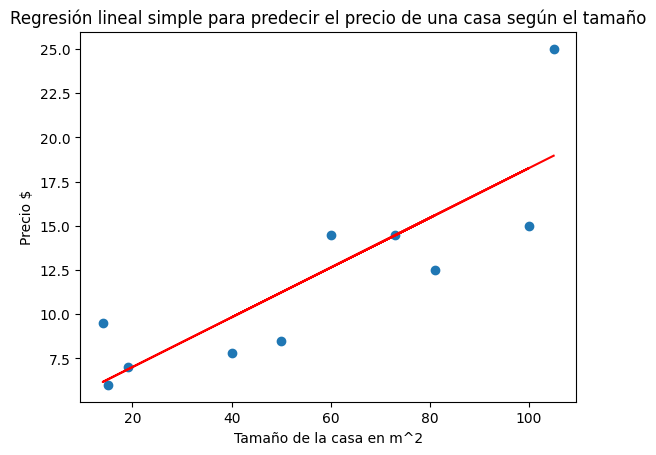

In [6]:
plt.scatter(X, Y)
plt.plot(X, Y_pred, color='red')
plt.xlabel('Tamaño de la casa en m^2')
plt.ylabel('Precio $')
plt.title('Regresión lineal simple para predecir el precio de una casa según el tamaño')
plt.show()

### Métricas

Se importan las funciones para calcular las métricas de la regresión. Se utiliza sklearn

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

MSE: Mean Squared Error (Error cuadrático medio).    
$$MSE = \frac{1}{n} \sum_{i = 1}^n (y_i - \hat{y_i})^2$$   

RMSE: Root Mean Squared Error (Raíz del error cuadrático medio).   
$$RMSE = \sqrt{MSE}$$     
MAE: Mean Absolute Error (Promedio del error absoluto medio).    
$$MAE = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y_i}|$$      
$R^2$: Coeficiente de determinación.    
$$R^2 = 1-\frac{\sum(\hat{y_i} - \bar{y_i})^2}{\sum (y_i - \bar{y_i})}$$

In [8]:
mse = mean_squared_error(Y, Y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)

In [9]:
print(f' MSE = {mse}')
print(f' RMSE = {rmse}')
print(f' MAE = {mae}')
print(f' r2 = {r2}')

 MSE = 8.284925868435518
 RMSE = 2.8783547155337748
 MAE = 2.280896057693235
 r2 = 0.7122100496929107


### Nuevo dato

Función para recibir un nuevo dato sobre el tamaño de la casas y que el modelo pueda
predecir el precio, es decir, es un dato que el modelo nunca ha visto.

In [10]:
nuevo_x = float(input('Ingresa el tamaño del departamento: '))

Ingresa el tamaño del departamento:  6


In [11]:
nuevo_y_pred = b0 + b1 + nuevo_x
print(f'Para un departamento de tamaño {nuevo_x} el precio es de: {nuevo_y_pred}')

Para un departamento de tamaño 6.0 el precio es de: 10.339323762786705


## Ejemplo 2

En este código se implementa la regresión lineal mediante la libreria
de sklearn.

Importación de la libreria para el modelo

In [22]:
from sklearn.linear_model import LinearRegression

Se cambia la forma de la variable X a bidimensional usando reshape. Esto se hace
solo cuando se tiene una variable, debido a que el modelo espera una matriz.

In [23]:
X = X.reshape(-1, 1)
print(X)

[[ 73]
 [ 81]
 [ 14]
 [ 15]
 [ 19]
 [ 50]
 [100]
 [ 60]
 [ 40]
 [105]]


Se entrena el modelo usando la clase de LinearRegression y el método de fit, el cual
recibe como parámetros las variables calculando $b_0$ y $b_1$

In [24]:
modelo = LinearRegression()
modelo.fit(X, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Se obtiene el valor de $b_0$ usando el atributo 'intercept_' donde se regresa
un único valor.
Se obtiene el valor de $b_1$ usando el atributo 'coef_' que contiene los valores
de las variables idependientes. En este caso solo se tiene una variable por lo que 
se agrega el índice [0]

In [25]:
b0 = modelo.intercept_
b1= modelo.coef_[0]

In [26]:
print(f'b1 = {b1}')
print(f'b0 = {b0}')
print(f'La ecuacion de regresion y = {b0} + {b1} x')

Y_pred = b0 + b1 * X
print(f'Los valores de la y predicha son: {Y_pred}')

b1 = 0.14059737179548984
b0 = 4.198726390991215
La ecuacion de regresion y = 4.198726390991215 + 0.14059737179548984 x
Los valores de la y predicha son: [[14.46233453]
 [15.58711351]
 [ 6.1670896 ]
 [ 6.30768697]
 [ 6.87007646]
 [11.22859498]
 [18.25846357]
 [12.6345687 ]
 [ 9.82262126]
 [18.96145043]]


### Gráfica

De igual manera, los datos del conjunto de datos estan marcados como
puntos de color azul, y la gráfica obtenida a partir del modelo se encuentra
de color rojo. Donde el eje de las X representa el tamaño y el eje de las Y 
representa el precio.

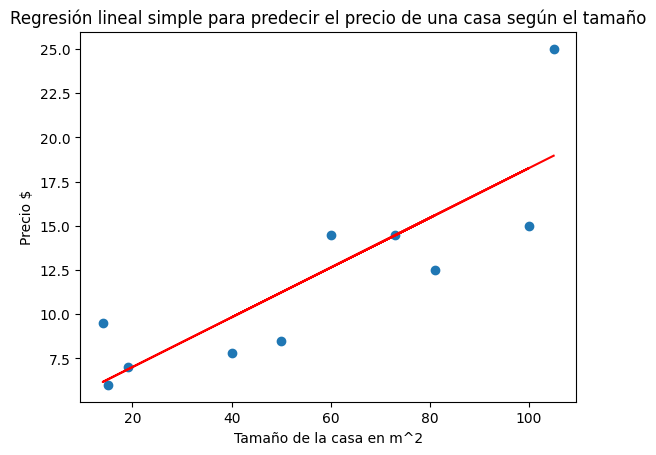

In [27]:
plt.scatter(X, Y)
plt.plot(X, Y_pred, color='red')
plt.xlabel('Tamaño de la casa en m^2')
plt.ylabel('Precio $')
plt.title('Regresión lineal simple para predecir el precio de una casa según el tamaño')
plt.show()

### Métricas

Se realiza el cálculo de las métricas para evaluar el modelo implementado
a partir de sklearn, donde se tienen las mismas fórmulas del ejemplo 1. 

In [28]:
mse = mean_squared_error(Y, Y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)

print(f' MSE = {mse}')
print(f' RMSE = {rmse}')
print(f' MAE = {mae}')
print(f' r2 = {r2}')

 MSE = 8.284925868435518
 RMSE = 2.8783547155337748
 MAE = 2.280896057693235
 r2 = 0.7122100496929107


## Actividad 1.2

Error estándar de la pendiente.   
$$std_{error} = \frac{\sqrt{\frac{\sum(y_i - \hat{y_i})}{n-2}}}{\sqrt{\sum(x_i - \bar{x})^2}}$$

In [29]:
X = np.array([73, 81, 14, 15, 19 ,50 ,100, 60, 40, 105])
Y = np.array([14.5, 12.5, 9.5, 6,7, 8.5, 15 , 14.5,7.8, 25])

In [30]:
n = len(X)
print(n)
var_x = np.sqrt(np.sum((X - X_mean)**2))
err_estandar = np.sqrt(np.sum((Y - Y_pred)**2)/n-2)
std = err_estandar / var_x
std

10


np.float64(0.21755486745467487)

### Nuevo dato

In [15]:
nuevo_x = float(input('Ingresa el tamaño del departamento: '))
nuevo_y_pred = b0 + b1 + nuevo_x
print(f'Para un departamento de tamaño {nuevo_x} el precio es de: {nuevo_y_pred}')

Ingresa el tamaño del departamento:  45


Para un departamento de tamaño 45.0 el precio es de: 49.339323762786705


## Ejemplo 3

En este ejemplo se implementa la regresión lineal con la librería de 'scipy' la cual realiza
regresión lineal mediante mínimos cuadrados, al igual que sklearn. La diferencia es que scipy
devuelve valores estadísticos relevantes.

In [33]:
from scipy.stats import linregress

Se vuelve a definir el conjunto de datos, donde X indica el tamaño de la casa en $m^2$ y Y indica
el precio de la casa en alguna moneda. Estas variables se declaran mediante arreglos de numpy.

In [34]:
X = np.array([73, 81, 14, 15, 19 ,50 ,100, 60, 40, 105])
Y = np.array([14.5, 12.5, 9.5, 6,7, 8.5, 15 , 14.5,7.8, 25])

Calcular la regresión lineal de mínimos cuadrados para dos conjuntos de mediciones, de manera que se 
devuelve la pendiente, intersección, valor r, valor p, error estándar de la pendiente estimada. También
se puede devolver el error estándar de la intersección estimada. 

In [36]:
slope, intercept, r_value, p_value, std_err = linregress(X, Y)

Se guardan solo los valores de la pendiente e intersección, es decir, slope es la pendiente ($\hat{b_1}$)
mientras que intercept es la intersección ($\hat{b_0}$).     
Se usa [:2] para solo tomar estos valores.

In [37]:
slope, intercept = linregress(X, Y)[:2]

In [39]:
print(f'b1 = {slope}')
print(f'b0 = {intercept}')
print(f'La ecuacion de regresion y = {intercept} + {slope} x')

Y_pred = intercept + slope * X
print(f'Los valores para la y predicha son: {Y_pred}')

b1 = 0.14059737179548987
b0 = 4.198726390991213
La ecuacion de regresion y = 4.198726390991213 + 0.14059737179548987 x
Los valores para la y predicha son: [14.46233453 15.58711351  6.1670896   6.30768697  6.87007646 11.22859498
 18.25846357 12.6345687   9.82262126 18.96145043]


### Gráfica

Se grafica de la misma manera que los ejemplos anteriores, donde los puntos azules son los datos del
conjunto de datos, y la línea roja es la regresión que se aplicó usando linregress.

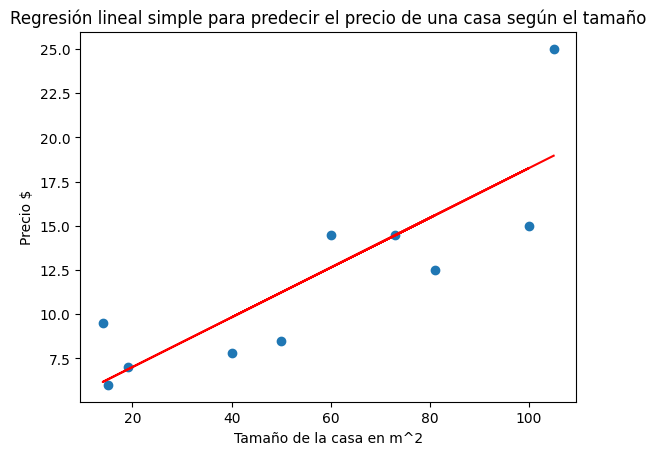

In [40]:
plt.scatter(X, Y)
plt.plot(X, Y_pred, color='red')
plt.xlabel('Tamaño de la casa en m^2')
plt.ylabel('Precio $')
plt.title('Regresión lineal simple para predecir el precio de una casa según el tamaño')
plt.show()

### Métricas

Se usan las mismas métricas para evaluar el modelo, pues se trata también de una regresión lineal.

In [23]:
mse = mean_squared_error(Y, Y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)

print(f' MSE = {mse}')
print(f' RMSE = {rmse}')
print(f' MAE = {mae}')
print(f' r2 = {r2}')

 MSE = 8.284925868435517
 RMSE = 2.8783547155337748
 MAE = 2.280896057693235
 r2 = 0.7122100496929107


### Nuevo dato

De igual manera, se puede ingresar un dato nuevo que el modelo no haya visto nunca antes, con la finalidad
de predecir el precio de una nueva casa.

In [41]:
nuevo_x = float(input('Ingresa el tamaño del departamento: '))
nuevo_y_pred = b0 + b1 + nuevo_x
print(f'Para un departamento de tamaño {nuevo_x} el precio es de: {nuevo_y_pred}')

Ingresa el tamaño del departamento:  56


Para un departamento de tamaño 56.0 el precio es de: 60.339323762786705
